In [1]:
import pandas as pd
import numpy as np

from sklearn.ensemble import IsolationForest

import matplotlib.pyplot as plt

In [2]:
hourly_df = pd.read_csv(
    "../data/processed/hourly_energy.csv"
)

hourly_df["x_Timestamp"] = pd.to_datetime(
    hourly_df["x_Timestamp"]
)

In [3]:
meter_df = hourly_df[
    hourly_df["meter"] == "BR02"
].copy()

meter_df = meter_df.sort_values(
    "x_Timestamp"
)

In [4]:
meter_df["hour"] = meter_df["x_Timestamp"].dt.hour
meter_df["dayofweek"] = meter_df["x_Timestamp"].dt.dayofweek

In [5]:
features = meter_df[
    ["t_kWh", "hour", "dayofweek"]
]

In [7]:
model = IsolationForest(
    contamination=0.01,
    random_state=42
)

meter_df["anomaly"] = model.fit_predict(
    features
)

In [8]:
meter_df["anomaly"].value_counts()

anomaly
 1    14422
-1      146
Name: count, dtype: int64

In [9]:
anomalies = meter_df[
    meter_df["anomaly"] == -1
]

print(anomalies.shape)

(146, 7)


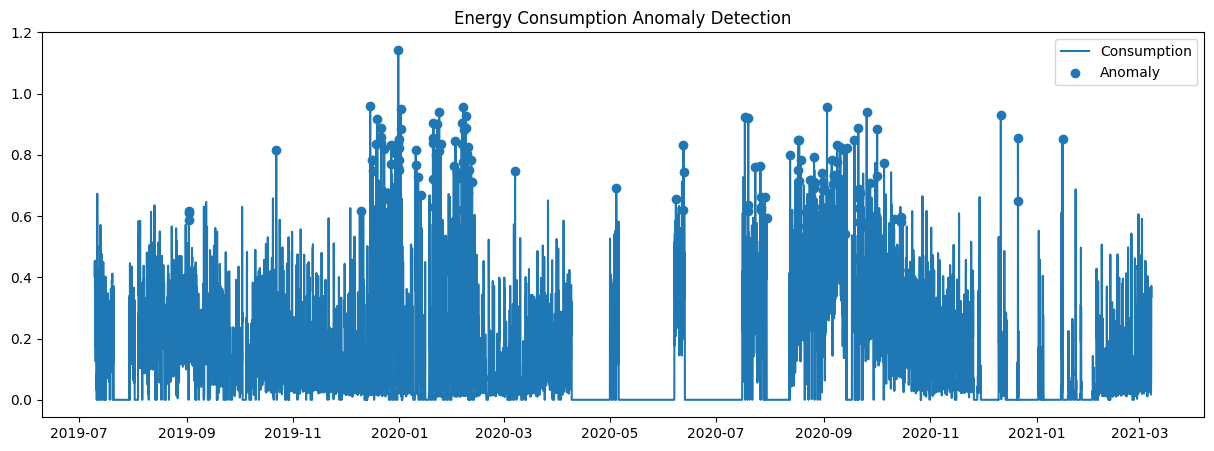

In [10]:
plt.figure(figsize=(15,5))

plt.plot(
    meter_df["x_Timestamp"],
    meter_df["t_kWh"],
    label="Consumption"
)

plt.scatter(
    anomalies["x_Timestamp"],
    anomalies["t_kWh"],
    label="Anomaly"
)

plt.legend()

plt.title(
    "Energy Consumption Anomaly Detection"
)

plt.savefig(
    "../reports/figures/anomaly_detection.png"
)

plt.show()

In [11]:
anomalies[
    ["x_Timestamp", "t_kWh"]
].sort_values(
    "t_kWh",
    ascending=False
).head(20)

,x_Timestamp,t_kWh
4186,2019-12-31 10:00:00,1.143
3799,2019-12-15 07:00:00,0.958
10096,2020-09-02 16:00:00,0.957
5085,2020-02-06 21:00:00,0.955
4221,2020-01-01 21:00:00,0.951
10643,2020-09-25 11:00:00,0.940
4750,2020-01-23 22:00:00,0.939
12492,2020-12-11 12:00:00,0.930
5119,2020-02-08 07:00:00,0.926
8964,2020-07-17 12:00:00,0.925


In [12]:
meter_df["anomaly"].value_counts()

anomaly
 1    14422
-1      146
Name: count, dtype: int64

In [13]:
anomalies.shape

(146, 7)

In [14]:
anomalies.to_csv(
    "../reports/anomalies_detected.csv",
    index=False
)